In [1]:
import pandas as pd

df = pd.read_csv('../data/creditcard.csv')
df.shape

(284807, 31)

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [3]:
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

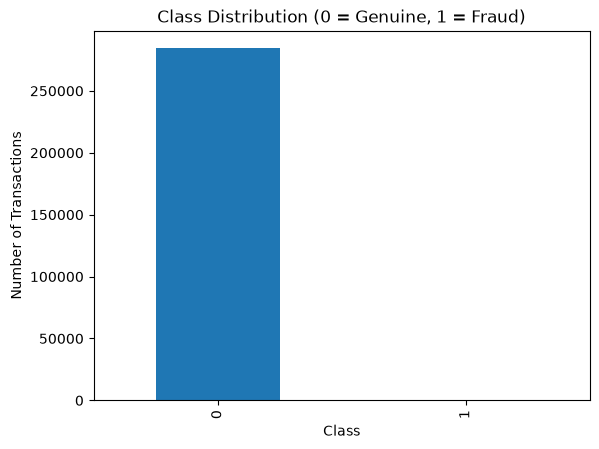

In [4]:
import matplotlib.pyplot as plt

df['Class'].value_counts().plot(kind='bar')
plt.title('Class Distribution (0 = Genuine, 1 = Fraud)')
plt.xlabel('Class')
plt.ylabel('Number of Transactions')
plt.show()

In [5]:
df.groupby('Class')['Amount'].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,88.291022,250.105092,0.0,5.65,22.00,77.05,25691.16
1,492.0,122.211321,256.683288,0.0,1.00,9.25,105.89,2125.87


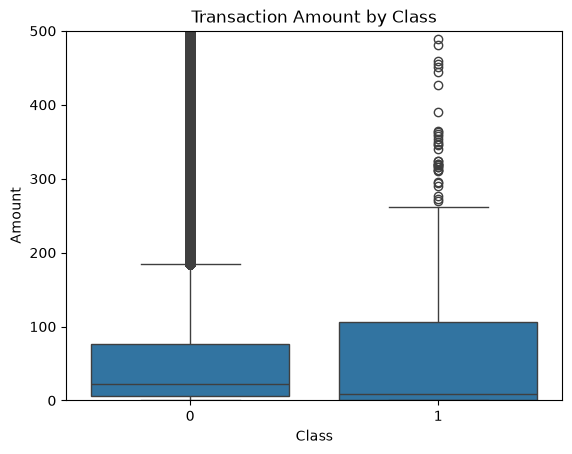

In [6]:
import seaborn as sns

sns.boxplot(x='Class', y='Amount', data=df)
plt.title('Transaction Amount by Class')
plt.ylim(0, 500)  # zooming in, since a few huge outliers otherwise squash the chart
plt.show()

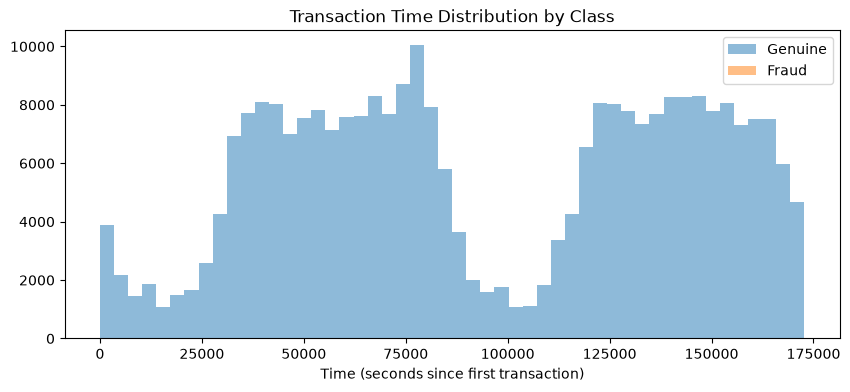

In [7]:
plt.figure(figsize=(10,4))
plt.hist(df[df['Class']==0]['Time'], bins=50, alpha=0.5, label='Genuine')
plt.hist(df[df['Class']==1]['Time'], bins=50, alpha=0.5, label='Fraud')
plt.legend()
plt.title('Transaction Time Distribution by Class')
plt.xlabel('Time (seconds since first transaction)')
plt.show()

In [8]:
correlations = df.corr()['Class'].sort_values(ascending=False)
correlations


Class     1.000000
V11       0.154876
V4        0.133447
V2        0.091289
V21       0.040413
V19       0.034783
V20       0.020090
V8        0.019875
V27       0.017580
V28       0.009536
Amount    0.005632
V26       0.004455
V25       0.003308
V22       0.000805
V23      -0.002685
V15      -0.004223
V13      -0.004570
V24      -0.007221
Time     -0.012323
V6       -0.043643
V5       -0.094974
V9       -0.097733
V1       -0.101347
V18      -0.111485
V7       -0.187257
V3       -0.192961
V16      -0.196539
V10      -0.216883
V12      -0.260593
V14      -0.302544
V17      -0.326481
Name: Class, dtype: float64

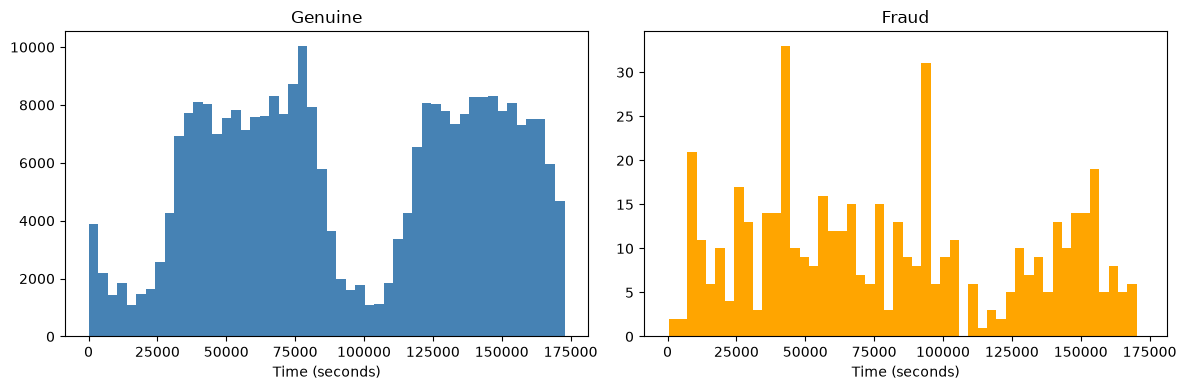

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

axes[0].hist(df[df['Class']==0]['Time'], bins=50, color='steelblue')
axes[0].set_title('Genuine')
axes[0].set_xlabel('Time (seconds)')

axes[1].hist(df[df['Class']==1]['Time'], bins=50, color='orange')
axes[1].set_title('Fraud')
axes[1].set_xlabel('Time (seconds)')

plt.tight_layout()
plt.show()